# Sentinela — 03. Motor de Triagem (Entrega Final)

objetivo de 'identificar, no momento da abertura, incidentes com maior propensão a serem
encerrados como *Sem Intervenção*, usando um critério conservador para apoiar a priorização
da revisão humana. O modelo não descarta, não fecha e não decide automaticamente — apenas
prioriza a fila de revisão.

Versão consolidada após auditoria de robustez. Configuração final: Logistic Regression,
sem `Grupo designado`, threshold 0,7 como ponto de corte operacional.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
import os

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH = '/content/LWDATASET.xlsx'
GRAFICOS_DIR = '../outputs/graficos'
os.makedirs(GRAFICOS_DIR, exist_ok=True)

RANDOM_STATE = 42

## 1. Objetivo do Motor de Triagem

```
INCIDENTE ABERTO → features disponíveis no instante t0 → score → threshold operacional
                                                                        ↓
                                                    prioridade de revisão humana (não descarte)
```

Target: `1 = Sem Intervenção` (incidente terminou sem qualquer trabalho humano de diagnóstico
ou correção) · `0 = exigiu alguma forma de tratamento/intervenção`.

## 2. Preparação dos Dados e Target

`Status = 'Encerrado Automaticamente'` **não** é tratado como `Sem Intervenção`: possui
código de fechamento e solução preenchidos em fração relevante dos casos, evidenciando
diagnóstico prévio. Apenas `Status = 'Sem Intervenção'` tem 0% de preenchimento em ambos os
campos — critério adotado para o target.

In [ ]:
df = pd.read_excel(RAW_PATH, sheet_name='Dataset Geral')
df['Aberto'] = pd.to_datetime(df['Aberto'])
print('Shape:', df.shape, '| Período:', df['Aberto'].min().date(), 'a', df['Aberto'].max().date())

Shape: (122543, 19) | Período: 2023-01-02 a 2025-12-31


In [ ]:
auditoria_status = df.groupby('Status').agg(
    tem_codigo_fechamento=('Código de fechamento', lambda s: s.notna().mean()),
    tem_solucao=('Solução', lambda s: s.notna().mean()),
    duracao_mediana=('Duração', 'median'),
    n=('Número', 'count')
).round(3)
auditoria_status

,tem_codigo_fechamento,tem_solucao,duracao_mediana,n
Status,,,,
Aguardando Problema,0.000,0.000,14537.0,1
Encerrado,0.940,0.331,3144.0,15339
Encerrado Automaticamente,0.983,0.381,7873.0,26830
Sem Intervenção,0.000,0.000,334.0,80373


In [ ]:
df_mod = df[df['Status'] != 'Aguardando Problema'].copy()
df_mod['target'] = (df_mod['Status'] == 'Sem Intervenção').astype(int)

# regime recente: distribuição do target muda estruturalmente a partir de set/2025
regime = df_mod[df_mod['Aberto'] >= '2025-09-01'].copy()
print('Observações no regime de modelagem:', len(regime))
print('Distribuição do target:', regime['target'].value_counts(normalize=True).round(3).to_dict())

Observações no regime de modelagem: 93423
Distribuição do target: {1: 0.859, 0: 0.141}


## 3. Auditoria de Features e Leakage

Configuração final: **sem `Grupo designado`**. A auditoria de robustez mostrou perda de
desempenho pequena ao removê-lo (< 1,3 p.p. de precision), e sua remoção elimina a
dependência de uma informação cuja disponibilidade no instante exato da abertura não está
confirmada no dicionário de dados.

In [ ]:
auditoria_features = pd.DataFrame([
    {'Feature': 'Prioridade', 'Utilizada?': 'SIM', 'Motivo': 'Atribuída na criação do incidente'},
    {'Feature': 'Aberto por', 'Utilizada?': 'SIM', 'Motivo': 'Origem definida na criação'},
    {'Feature': 'Calendário (dia/mês/hora/fim de semana)', 'Utilizada?': 'SIM', 'Motivo': 'Derivado do timestamp de abertura'},
    {'Feature': 'Grupo designado', 'Utilizada?': 'NÃO', 'Motivo': 'Disponibilidade no instante da abertura não confirmada; removida na configuração conservadora'},
    {'Feature': 'Produto/Categoria/Subcategoria', 'Utilizada?': 'NÃO', 'Motivo': 'Preenchimento majoritariamente ausente (~36%)'},
    {'Feature': 'Item de configuração', 'Utilizada?': 'NÃO', 'Motivo': 'Cardinalidade muito alta (9.171 valores únicos)'},
    {'Feature': 'Descrição resumida', 'Utilizada?': 'NÃO', 'Motivo': 'Texto livre, exigiria NLP — fora de escopo'},
    {'Feature': 'Resolvido / Encerrado / Duração / Código de fechamento / Solução', 'Utilizada?': 'PROIBIDA', 'Motivo': 'Só existem após o fechamento — leakage'},
    {'Feature': 'Status', 'Utilizada?': 'PROIBIDA', 'Motivo': 'É a fonte do target'},
    {'Feature': 'Entrou para KPI? / KPI Violado?', 'Utilizada?': 'PROIBIDA', 'Motivo': 'Derivados do status final'},
    {'Feature': 'Incidente Pai', 'Utilizada?': 'PROIBIDA', 'Motivo': 'Momento de vinculação incerto — excluído por precaução'},
])
auditoria_features

,Feature,Utilizada?,Motivo
0,Prioridade,SIM,Atribuída na criação do incidente
1,Aberto por,SIM,Origem definida na criação
2,Calendário (dia/mês/hora/fim de semana),SIM,Derivado do timestamp de abertura
3,Grupo designado,NÃO,Disponibilidade no instante da abertura não co...
4,Produto/Categoria/Subcategoria,NÃO,Preenchimento majoritariamente ausente (~36%)
5,Item de configuração,NÃO,Cardinalidade muito alta (9.171 valores únicos)
6,Descrição resumida,NÃO,"Texto livre, exigiria NLP — fora de escopo"
7,Resolvido / Encerrado / Duração / Código de fe...,PROIBIDA,Só existem após o fechamento — leakage
8,Status,PROIBIDA,É a fonte do target
9,Entrou para KPI? / KPI Violado?,PROIBIDA,Derivados do status final


In [ ]:
regime['dia_semana'] = regime['Aberto'].dt.dayofweek
regime['mes'] = regime['Aberto'].dt.month
regime['hora'] = regime['Aberto'].dt.hour
regime['fim_de_semana'] = regime['dia_semana'].isin([5, 6]).astype(int)

CAT_FEATURES = ['Prioridade', 'Aberto por']
NUM_FEATURES = ['dia_semana', 'mes', 'hora', 'fim_de_semana']
FEATURES = CAT_FEATURES + NUM_FEATURES
FEATURES

['Prioridade', 'Aberto por', 'dia_semana', 'mes', 'hora', 'fim_de_semana']

## 4. Estratégia de Validação Temporal

Walk-forward com 3 janelas mensais, treino sempre expandindo, teste sempre no mês seguinte.
Nenhum split aleatório.

In [ ]:
janelas = [
    ('2025-09-01', '2025-10-01', '2025-10-01', '2025-11-01'),
    ('2025-09-01', '2025-11-01', '2025-11-01', '2025-12-01'),
    ('2025-09-01', '2025-12-01', '2025-12-01', '2026-01-01'),
]

for i, (tr_s, tr_e, te_s, te_e) in enumerate(janelas, 1):
    train = regime[(regime['Aberto'] >= tr_s) & (regime['Aberto'] < tr_e)]
    test = regime[(regime['Aberto'] >= te_s) & (regime['Aberto'] < te_e)]
    print(f"Janela {i}: treino {tr_s}→{tr_e} (n={len(train)}) | teste {te_s}→{te_e} (n={len(test)})")

Janela 1: treino 2025-09-01→2025-10-01 (n=21561) | teste 2025-10-01→2025-11-01 (n=23017)
Janela 2: treino 2025-09-01→2025-11-01 (n=44578) | teste 2025-11-01→2025-12-01 (n=21524)
Janela 3: treino 2025-09-01→2025-12-01 (n=66102) | teste 2025-12-01→2026-01-01 (n=27321)


## 5. Baseline — Regra Simples

Regra derivada exclusivamente do treino da Janela 1 (sem olhar teste):

```
SE Aberto por == 'Monitoramento' E Prioridade em ['3 - Média','4 - Baixa','5 - Muito Baixa']
ENTÃO previsão = Sem Intervenção (1)  SENÃO previsão = 0
```

In [ ]:
def regra_simples(row):
    return 1 if (row['Aberto por'] == 'Monitoramento' and
                 row['Prioridade'] in ['3 - Média', '4 - Baixa', '5 - Muito Baixa']) else 0

def metricas_confusao(y_true, y_pred, n_pos_label=1):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    sinalizados = tp + fp
    precision = tp / sinalizados if sinalizados > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * precision * recall / (precision + recall) if precision and recall and (precision + recall) > 0 else np.nan
    cobertura = sinalizados / len(y_true)
    fdr = fp / sinalizados if sinalizados > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return dict(tp=tp, fp=fp, tn=tn, fn=fn, precision=precision, recall=recall, f1=f1,
                cobertura=cobertura, fdr=fdr, fpr=fpr, n=len(y_true))

resultados_regra = []
for i, (tr_s, tr_e, te_s, te_e) in enumerate(janelas, 1):
    test = regime[(regime['Aberto'] >= te_s) & (regime['Aberto'] < te_e)]
    pred = test.apply(regra_simples, axis=1).values
    m = metricas_confusao(test['target'].values, pred)
    resultados_regra.append((i, m))

pd.DataFrame([{'Janela': i, 'Precision': round(m['precision'], 4), 'Recall': round(m['recall'], 4),
               'Cobertura': round(m['cobertura'], 4), 'FP': m['fp'], 'FN': m['fn']}
              for i, m in resultados_regra])

,Janela,Precision,Recall,Cobertura,FP,FN
0,1,0.9165,0.9172,0.8245,1585,1571
1,2,0.9412,0.8931,0.8159,1032,1978
2,3,0.9608,0.9461,0.9003,964,1346


## 6. Modelo Final — Logistic Regression

A Logistic Regression foi mantida por apresentar comportamento operacional mais conservador
e estabilidade temporal adequada para a triagem. `class_weight='balanced'` compensa o
desbalanceamento residual do target.

In [ ]:
def treina_modelo(train, test):
    pipe = Pipeline([
        ('pre', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)],
                                   remainder='passthrough')),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    pipe.fit(train[FEATURES], train['target'])
    proba = pipe.predict_proba(test[FEATURES])[:, 1]
    return pipe, proba

pipelines = {}
probas_janela = {}
for i, (tr_s, tr_e, te_s, te_e) in enumerate(janelas, 1):
    train = regime[(regime['Aberto'] >= tr_s) & (regime['Aberto'] < tr_e)]
    test = regime[(regime['Aberto'] >= te_s) & (regime['Aberto'] < te_e)]
    pipe, proba = treina_modelo(train, test)
    pipelines[i] = pipe
    probas_janela[i] = (test['target'].values, proba)
print('Modelos treinados:', list(pipelines.keys()))

Modelos treinados: [1, 2, 3]


## 7. Threshold Operacional

O valor 0,7 é utilizado como ponto de corte operacional do score do modelo. A auditoria de
calibração mostrou que esse score não deve ser interpretado como probabilidade literal
(ver Seção 10).

In [ ]:
THRESHOLD = 0.7

resultados_ml = []
for i in [1, 2, 3]:
    y_true, proba = probas_janela[i]
    pred = (proba >= THRESHOLD).astype(int)
    m = metricas_confusao(y_true, pred)
    resultados_ml.append((i, m))

tabela_ml = pd.DataFrame([{'Janela': i, 'Precision': round(m['precision'], 4), 'Recall': round(m['recall'], 4),
                           'F1': round(m['f1'], 4), 'Cobertura': round(m['cobertura'], 4),
                           'FP': m['fp'], 'FN': m['fn'], 'FPR': round(m['fpr'], 4)} for i, m in resultados_ml])
tabela_ml

,Janela,Precision,Recall,F1,Cobertura,FP,FN,FPR
0,1,0.9432,0.7273,0.8213,0.6353,830,5172,0.2048
1,2,0.9630,0.7251,0.8273,0.6475,516,5087,0.1711
2,3,0.9691,0.6073,0.7467,0.5729,483,9810,0.2061


## 8. Validação Temporal

Resultado **agregado** (pool das 3 janelas de teste) e resultado da **janela mais recente**,
reportados separadamente para evitar cherry-picking.

In [ ]:
y_pool = np.concatenate([probas_janela[i][0] for i in [1, 2, 3]])
p_pool = np.concatenate([probas_janela[i][1] for i in [1, 2, 3]])
pred_pool = (p_pool >= THRESHOLD).astype(int)
m_agregado = metricas_confusao(y_pool, pred_pool)

m_recente = resultados_ml[2][1]  # janela 3

print('=== AGREGADO (3 janelas) ===')
fpr_agregado = m_agregado['fp'] / (m_agregado['fp'] + m_agregado['tn'])

print(f"Precision={m_agregado['precision']:.4f}  Recall={m_agregado['recall']:.4f}  F1={m_agregado['f1']:.4f}  "
      f"Cobertura={m_agregado['cobertura']:.4f}  FP={m_agregado['fp']}  FN={m_agregado['fn']}  FPR={fpr_agregado:.4f}")
print()
print('=== JANELA MAIS RECENTE (Janela 3) ===')
print(f"Precision={m_recente['precision']:.4f}  Recall={m_recente['recall']:.4f}  F1={m_recente['f1']:.4f}  "
      f"Cobertura={m_recente['cobertura']:.4f}  FP={m_recente['fp']}  FN={m_recente['fn']}  FPR={m_recente['fpr']:.4f}")

=== AGREGADO (3 janelas) ===
Precision=0.9586  Recall=0.6786  F1=0.7947  Cobertura=0.6152  FP=1829  FN=20069  FPR=0.1943

=== JANELA MAIS RECENTE (Janela 3) ===
Precision=0.9691  Recall=0.6073  F1=0.7467  Cobertura=0.5729  FP=483  FN=9810  FPR=0.2061


A precision permaneceu elevada nas três janelas, enquanto recall e cobertura apresentaram
redução no período mais recente. O comportamento é defensável para o MVP, mas exige
monitoramento temporal.

## 9. Matriz de Confusão e Risco Operacional (Janela mais recente)

- **TP**: sinalizado como Sem Intervenção e realmente Sem Intervenção.
- **FP**: sinalizado como Sem Intervenção, mas realmente exigia intervenção — **erro operacional mais sensível**.
- **TN**: não sinalizado, e realmente exigia intervenção.
- **FN**: não sinalizado, mas era Sem Intervenção — custo de oportunidade, não risco.

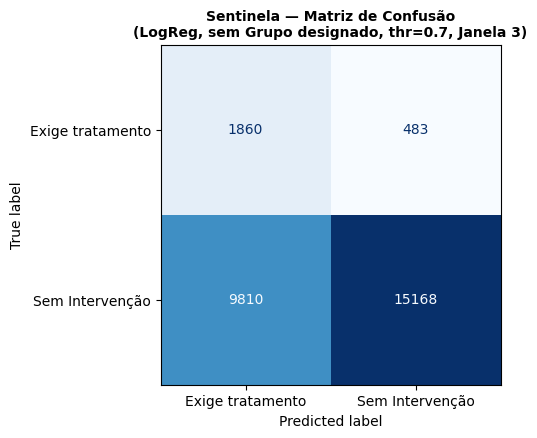

In [ ]:
y_true_j3, proba_j3 = probas_janela[3]
pred_j3 = (proba_j3 >= THRESHOLD).astype(int)
cm_j3 = confusion_matrix(y_true_j3, pred_j3, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4.5))
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm_j3, display_labels=['Exige tratamento', 'Sem Intervenção']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Sentinela — Matriz de Confusão\n(LogReg, sem Grupo designado, thr=0.7, Janela 3)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/matriz_confusao_final.png', dpi=150)
plt.show()

In [ ]:
tp, fp, fn = m_recente['tp'], m_recente['fp'], m_recente['fn']
tn = m_recente['tn']
precision = m_recente['precision']
fdr = m_recente['fdr']
fpr = m_recente['fpr']

print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print()
print(f'Precision = TP/(TP+FP) = {precision:.4f}')
print(f'FDR       = FP/(TP+FP) = {fdr:.4f}   (Precision = 1 - FDR → {abs((1-fdr)-precision) < 1e-9})')
print(f'FPR       = FP/(FP+TN) = {fpr:.4f}   (Precision ≠ 1 - FPR → 1-FPR = {1-fpr:.4f})')
print()
print('FPR — Taxa de Incidentes com Intervenção Indevidamente Sinalizados: métrica de risco operacional.')

TP=15168  FP=483  TN=1860  FN=9810

Precision = TP/(TP+FP) = 0.9691
FDR       = FP/(TP+FP) = 0.0309   (Precision = 1 - FDR → True)
FPR       = FP/(FP+TN) = 0.2061   (Precision ≠ 1 - FPR → 1-FPR = 0.7939)

FPR — Taxa de Incidentes com Intervenção Indevidamente Sinalizados: métrica de risco operacional.


## 10. Calibração do Score

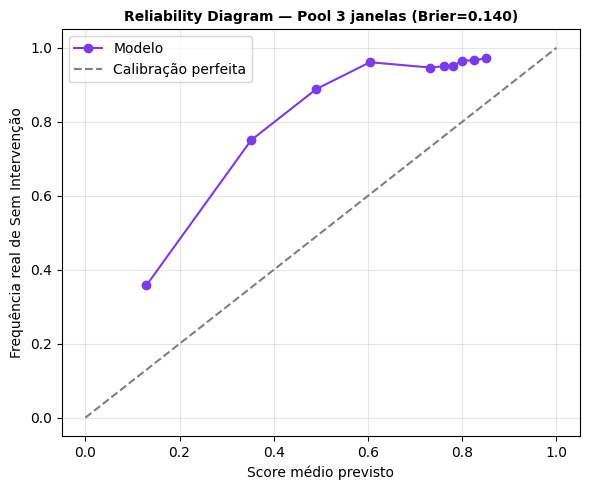

Brier Score agregado: 0.1396


In [ ]:
brier_pool = brier_score_loss(y_pool, p_pool)
frac_pos, mean_pred = calibration_curve(y_pool, p_pool, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_pred, frac_pos, marker='o', color='#7c3aed', label='Modelo')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
ax.set_xlabel('Score médio previsto')
ax.set_ylabel('Frequência real de Sem Intervenção')
ax.set_title(f'Reliability Diagram — Pool 3 janelas (Brier={brier_pool:.3f})', fontsize=10, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{GRAFICOS_DIR}/calibration_curve.png', dpi=150)
plt.show()

print(f'Brier Score agregado: {brier_pool:.4f}')

As probabilidades apresentam subconfiança sistemática. O score é útil para ordenação e
aplicação de um ponto de corte operacional, mas não deve ser interpretado como probabilidade
literal.

## 11. Comparação Regra × Modelo (Janela mais recente)

In [ ]:
m_regra_j3 = resultados_regra[2][1]

comparacao = pd.DataFrame([
    {'Método': 'Regra simples', 'Precision': round(m_regra_j3['precision'], 4),
     'Cobertura': round(m_regra_j3['cobertura'], 4), 'FP': m_regra_j3['fp'], 'FN': m_regra_j3['fn']},
    {'Método': 'LogReg final (sem Grupo, thr=0.7)', 'Precision': round(m_recente['precision'], 4),
     'Cobertura': round(m_recente['cobertura'], 4), 'FP': m_recente['fp'], 'FN': m_recente['fn']},
])
comparacao

,Método,Precision,Cobertura,FP,FN
0,Regra simples,0.9608,0.9003,964,1346
1,"LogReg final (sem Grupo, thr=0.7)",0.9691,0.5729,483,9810


A regra simples cobre mais incidentes. A Logistic Regression é mais conservadora e reduz
falsos positivos, priorizando segurança na triagem.

## 12. Limitações

- Redução de recall/cobertura na janela mais recente.
- Score não calibrado — não deve ser lido como probabilidade literal.
- Necessidade de monitorar drift temporal em produção.
- Threshold operacional (0,7) pode precisar de revisão futura.
- Modelo apoia decisão humana; não automatiza encerramento de incidentes.

## 13. Conclusão

O Motor de Triagem identificou casos de Sem Intervenção com precision agregada próxima de
96%, utilizando apenas informações disponíveis na abertura. A configuração conservadora
(sem `Grupo designado`) reduz falsos positivos frente à regra simples, em troca de menor
cobertura, e elimina uma dependência de disponibilidade temporal não confirmada. O modelo é
utilizado como apoio à priorização da revisão humana, não como automação de encerramento.

O modelo conservador foi escolhido por manter desempenho semelhante ao modelo com `Grupo
designado`, com premissas temporais mais seguras.

**Status: Validado com ressalvas.**